In [1]:
import fitsio
import numpy as np
import ultraplot as uplt

/Users/beckermr/mambaforge/envs/work/lib/python3.12/site-packages/ultraplot/__init__.py:77: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


In [30]:
d = {
    band: fitsio.read(f"~/Downloads/gmix-5gauss-dp2-{band}.fits")
    for band in ["g", "r", "i", "z"]
}

In [36]:
import datetime

obs_times = {
    band: [
        datetime.datetime.strptime(str(d[band]["visit"][i])[:8], "%Y%m%d")
        for i in range(len(d[band]))
    ]
    for band in ["g", "r", "i", "z"]
}

In [ ]:
early_ops = [
    datetime.datetime(year=2025, month=10, day=26),
    datetime.datetime(year=2026, month=4, day=25)
]

msks = {}
for band in ["g", "r", "i", "z"]:

    jan_msk = np.array([
        (tm.year == 2026) and (tm.month == 1)
        for tm in obs_times[band]
    ])
    apr_msk = np.array([
        (tm.year == 2026) and (tm.month == 4) and (tm.day >= 14) and (tm.day <= 25)
        for tm in obs_times[band]
    ])
    eo_msk = np.array([
        (tm >= early_ops[0]) and (tm <= early_ops[1])
        for tm in obs_times[band]

    ])

    msks[band] = {"jan": jan_msk, "apr": apr_msk, "eo": eo_msk}

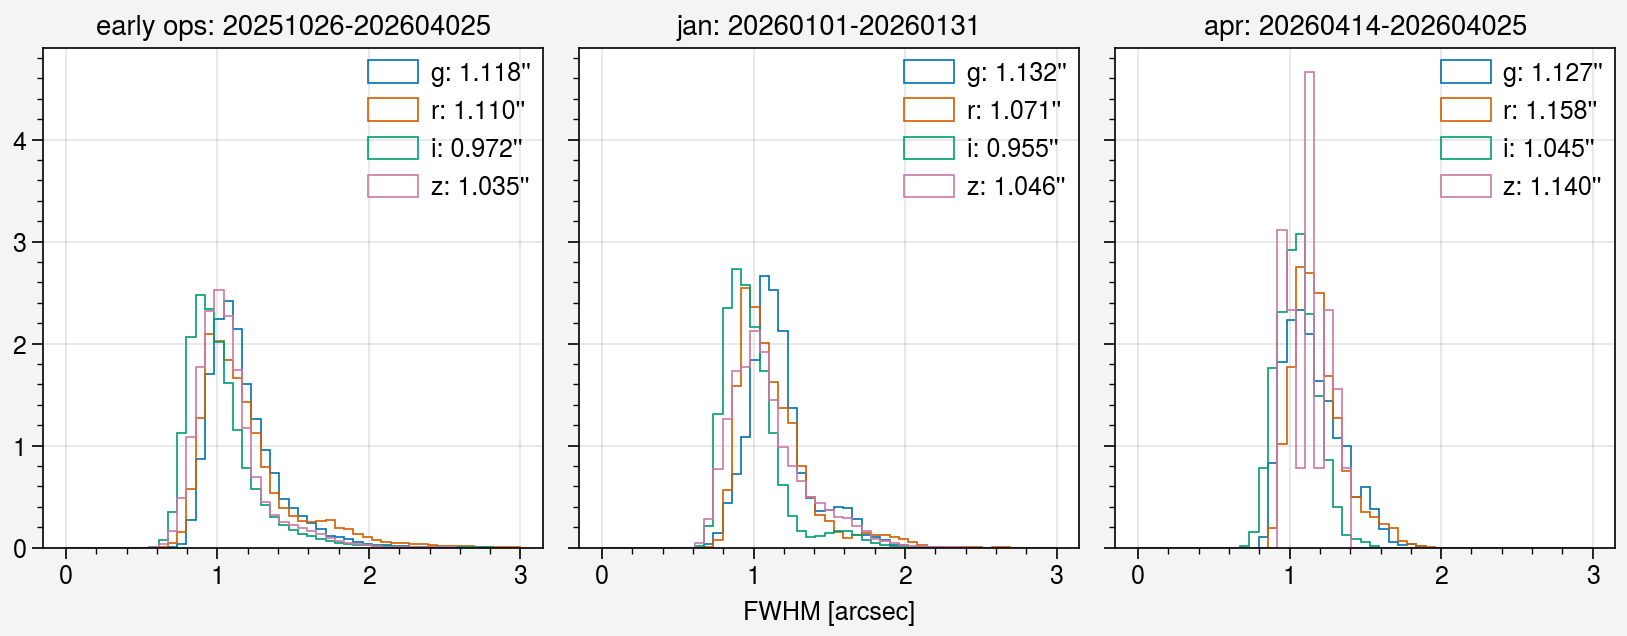

In [56]:
from ngmix.moments import T_to_fwhm


col = "gauss_T"

bins = np.linspace(0, 3, 50)

fig, axs = uplt.subplots(nrows=1, ncols=3)

for band in ["g", "r", "i", "z"]:
    ax = axs[0, 0]
    fwhm = T_to_fwhm(d[band][col][msks[band]["eo"] & (d[band]["flags"] == 0)])
    ax.hist(
        fwhm,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(fwhm):.3f}''"
    )
    ax.format(
        title="early ops: 20251026-202604025",
        xlabel="FWHM [arcsec]",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)
    ax = axs[0, 1]
    fwhm = T_to_fwhm(d[band][col][msks[band]["jan"] & (d[band]["flags"] == 0)])
    ax.hist(
        fwhm,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(fwhm):.3f}''"
    )
    ax.format(
        title="jan: 20260101-20260131",
        xlabel="FWHM [arcsec]",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)

    ax = axs[0, 2]
    fwhm = T_to_fwhm(d[band][col][msks[band]["apr"] & (d[band]["flags"] == 0)])
    ax.hist(
        fwhm,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(fwhm):.3f}''"
    )
    ax.format(
        title="apr: 20260414-202604025",
        xlabel="FWHM [arcsec]",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)

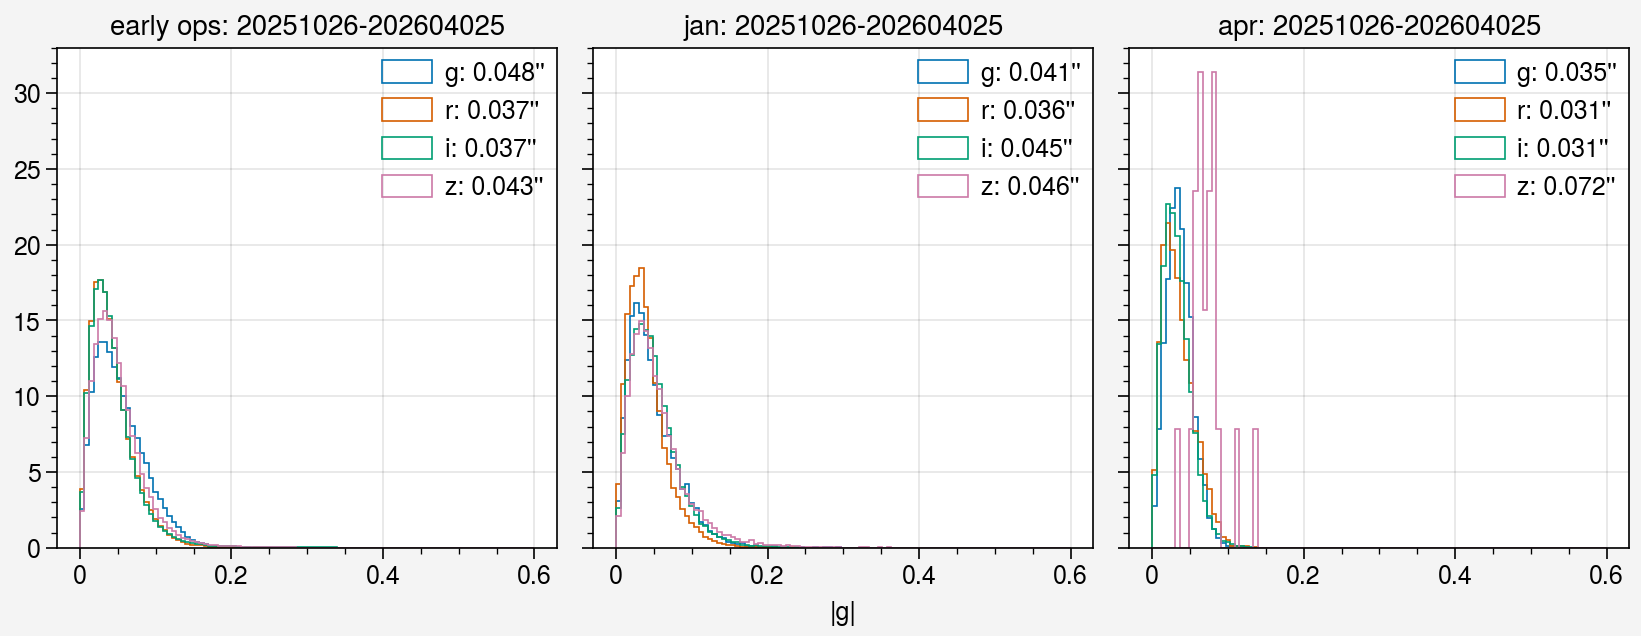

In [ ]:
from ngmix.moments import T_to_fwhm


col = "gauss_g"

bins = np.linspace(0, 0.6, 100)

fig, axs = uplt.subplots(nrows=1, ncols=3)

for band in ["g", "r", "i", "z"]:
    ax = axs[0, 0]
    g = np.sqrt(
        d[band][col][msks[band]["eo"] & (d[band]["flags"] == 0), 0]**2
        + d[band][col][msks[band]["eo"] & (d[band]["flags"] == 0), 1]**2
    )
    ax.hist(
        g,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(g):.3f}''"
    )
    ax.format(
        title="early ops: 20251026-202604025",
        xlabel="|g|",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)

    ax = axs[0, 1]
    g = np.sqrt(
        d[band][col][msks[band]["jan"] & (d[band]["flags"] == 0), 0]**2
        + d[band][col][msks[band]["jan"] & (d[band]["flags"] == 0), 1]**2
    )
    ax.hist(
        g,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(g):.3f}''"
    )
    ax.format(
        title="jan: 20251026-202604025",
        xlabel="|g|",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)

    ax = axs[0, 2]
    g = np.sqrt(
        d[band][col][msks[band]["apr"] & (d[band]["flags"] == 0), 0]**2
        + d[band][col][msks[band]["apr"] & (d[band]["flags"] == 0), 1]**2
    )
    ax.hist(
        g,
        bins=bins,
        filled=False,
        density=True,
        label=f"{band}: {np.median(g):.3f}''"
    )
    ax.format(
        title="apr: 20251026-202604025",
        xlabel="|g|",
    )
    ax.legend(loc="ur", frameon=False, ncols=1)